# **BIG DATA ANALYTICS PROJECT**

### **SUBMITTED BY :  AIMAN SARFRAZ (DSAI242102013)**

### **REGISTRATION NO. : DSAI242102013**

### **CLASS : BS-DASC-5A**

### **SUBMITTED TO : SIR MUHAMMAD WALEED**

# **PROJECT TITLE : SENTIMENT ANALYSIS ON TWITTER DATA**
#### This project aims to analyze user sentiments (positive/negative) from Twitter data using Big Data tools (PySpark). The goal is to process large-scale textual data efficiently and build a machine learning model to classify sentiments.


### **CREATING SESSION**
**PySpark is used instead of traditional Python to handle large-scale data efficiently using distributed computing.**

**SparkSession is the entry point of any PySpark application.**

**It allows us to:**

*  **Read large datasets**
*  **Perform distributed processing**
*  **Apply machine learning models**
*  **Here, we name our application SentimentAnalysis for identification.**

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("SentimentAnalysis").getOrCreate()

### **UPLOADING DATASET** Dataset contains Twitter tweets with sentiment labels.
**Each row includes:**
* **text → actual tweet**

* **sentiment → positive, negative, neutral**

**Twitter data is widely used for sentiment analysis because it reflects real-time public opinion.**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Tweets dataset.csv to Tweets dataset.csv


### **DATASET HEAD:** Displays first 5 rows to understand data structure.
**Helps verify:**

* **Columns**

* **Data format**

* **Missing values**

In [4]:
df = spark.read.csv("Tweets dataset.csv", header=True)
df.show(5, truncate=False)

+----------+---------------------------------------------------------------------------+-----------------------------------+---------+
|textID    |text                                                                       |selected_text                      |sentiment|
+----------+---------------------------------------------------------------------------+-----------------------------------+---------+
|cb774db0d1| I`d have responded, if I were going                                       |I`d have responded, if I were going|neutral  |
|549e992a42| Sooo SAD I will miss you here in San Diego!!!                             |Sooo SAD                           |negative |
|088c60f138|my boss is bullying me...                                                  |bullying me                        |negative |
|9642c003ef| what interview! leave me alone                                            |leave me alone                     |negative |
|358bd9e861| Sons of ****, why couldn`t they put them o

### **Selecting Required Columns:** Feature selection improves performance and reduces computation time.
**Removes unnecessary columns.**

**Focuses only on relevant features:**
* **Text → input**
* **Sentiment → output**

In [5]:
df = df.select("text", "sentiment")
df.show(5, truncate=False)

+---------------------------------------------------------------------------+---------+
|text                                                                       |sentiment|
+---------------------------------------------------------------------------+---------+
| I`d have responded, if I were going                                       |neutral  |
| Sooo SAD I will miss you here in San Diego!!!                             |negative |
|my boss is bullying me...                                                  |negative |
| what interview! leave me alone                                            |negative |
| Sons of ****, why couldn`t they put them on the releases we already bought|negative |
+---------------------------------------------------------------------------+---------+
only showing top 5 rows


### **REMOVING NEUTRAL SENTIMENT :** Binary classification is easier to train and often gives better results in sentiment analysis tasks.
**Converts problem into binary classification:**

* **Positive → 1**

* **Negative → 0**

**Neutral data is removed to:**

* **Simplify model**
* **Improve accuracy**

In [6]:
df = df.filter(df.sentiment != "neutral")
df.show(5 , truncate=False)

+---------------------------------------------------------------------------+---------+
|text                                                                       |sentiment|
+---------------------------------------------------------------------------+---------+
| Sooo SAD I will miss you here in San Diego!!!                             |negative |
|my boss is bullying me...                                                  |negative |
| what interview! leave me alone                                            |negative |
| Sons of ****, why couldn`t they put them on the releases we already bought|negative |
|2am feedings for the baby are fun when he is all smiles and coos           |positive |
+---------------------------------------------------------------------------+---------+
only showing top 5 rows


### **LABELLING ENCODING:** This step converts categorical data into numerical format for model training.  
**Machine learning models require numerical input. So:**

* **Positive → 1**

* **Negative → 0**                                                              

In [7]:
from pyspark.sql.functions import when

df = df.withColumn("label",
                   when(df.sentiment == "positive", 1).otherwise(0))

### **CLEANING DATASET:** Data cleaning is crucial because noisy text can reduce model accuracy.
**Converts text to lowercase → avoids duplication**

**Removes:**

* **URLs**

* **Special characters**

* **Numbers**

In [8]:
from pyspark.sql.functions import lower, regexp_replace

df = df.withColumn("text", lower(df["text"]))
df = df.withColumn("text", regexp_replace("text", r"http\S+", ""))  # remove URLs
df = df.withColumn("text", regexp_replace("text", r"[^a-zA-Z\s]", ""))  # remove punctuation/numbers

### **SENTIMENT VISUALIZATION:** Visualization helps in understanding dataset characteristics before training.                                          
**Shows distribution of sentiments.**

**Helps identify:**

* **Class imbalance**

* **Data trends**

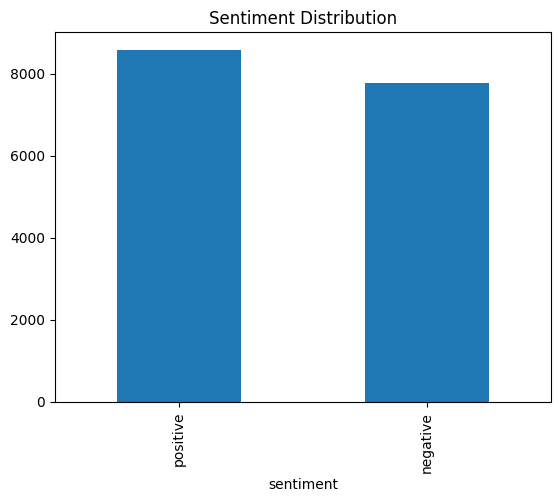

In [9]:
pdf = df.select("sentiment").toPandas()

import matplotlib.pyplot as plt

pdf['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

### **Feature Extraction:** It transforms text into machine-readable format using vectorization.
* **Tokenizer → splits text into words**

* **HashingTF → converts words into numeric vectors**

In [10]:
from pyspark.ml.feature import Tokenizer, HashingTF

tokenizer = Tokenizer(inputCol="text", outputCol="words")
wordsData = tokenizer.transform(df)

hashingTF = HashingTF(inputCol="words", outputCol="features")
featuredData = hashingTF.transform(wordsData)

### **Train-Test Split :** This ensures the model is evaluated on unseen data.
* **80% → training data**

* **20% → testing data**

In [11]:
train, test = featuredData.randomSplit([0.8, 0.2] , seed=42)

###**NAIVE BAYES CLASSIFICATION:** It assumes feature independence, making it suitable for high-dimensional text data.
Naive Bayes is used because:

* **Works well for text classification**
* **Fast and efficient**
* **Based on probability theory**

In [12]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(featuresCol="features", labelCol="label")
model = nb.fit(train)

### **PREDICTION**  Model predicts sentiment on test data.
Output includes:

* **Original text**

* **Predicted label**

In [13]:
predictions = model.transform(test)
predictions.select("text", "prediction").show(5, truncate=False)

+---------------------------------------------------------------------------------------+----------+
|text                                                                                   |prediction|
+---------------------------------------------------------------------------------------+----------+
|        beckett thanks so much                                                         |1.0       |
|     i love you guys get your  to australia in december for my birthday                |1.0       |
|     overwhelming lead for strawberry lemonade  my husband voted for banana fosters tho|1.0       |
|    hope all is ok                                                                     |1.0       |
|    shiv his place slowly i hope                                                       |1.0       |
+---------------------------------------------------------------------------------------+----------+
only showing top 5 rows


### **ACCURACY** is the ratio of correctly predicted observations to the total observations.
**Your result ≈ 85%**

**This indicates that the model performs well on unseen data.**

In [14]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")

accuracy = evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8539255552080075


### **F1 SCORE** F1 Score is the harmonic mean of Precision and Recall.
**The obtained F1 Score (~0.85) indicates that:**

* **The model maintains a good balance between Precision and Recall**

* **It is not biased toward one class (positive or negative)**

In [15]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")

f1 = evaluator.evaluate(predictions)
print("F1 Score:", f1)

F1 Score: 0.8532657475487109


### **Validation on Unseen Data:**                                           
The trained model is tested on new sentences that are not part of the dataset.
The model predicts whether the sentence is positive or negative, which shows that the model works on real-world input.

In [19]:
from pyspark.sql.functions import lower, regexp_replace

sample_text_data = spark.createDataFrame([("I LOVE this airline service, it was AmAzinG",), ("this flight is Terrible *** ",)], ["text"])

# Clean text
sample_text_data = sample_text_data.withColumn("text", lower(sample_text_data["text"]))
sample_text_data = sample_text_data.withColumn("text", regexp_replace("text", r"http\S+", ""))  # remove URLs
sample_text_data = sample_text_data.withColumn("text", regexp_replace("text", r"[^a-zA-Z\s]", "")) # remove punctuation/numbers

# Convert text to features using existing tokenizer and hashingTF
sample_words = tokenizer.transform(sample_text_data)
sample_features = hashingTF.transform(sample_words)

# Prediction
predictions = model.transform(sample_features)

predictions.select("text", "prediction").show(truncate=False)

+------------------------------------------+----------+
|text                                      |prediction|
+------------------------------------------+----------+
|i love this airline service it was amazing|1.0       |
|this flight is terrible                   |0.0       |
+------------------------------------------+----------+

